In [ ]:
# Install required packages
!pip install -q pdfplumber pymupdf pytesseract pdf2image opencv-python tabulate tqdm pdfminer.six pypdf camelot-py[cv]
!apt-get install -y poppler-utils tesseract-ocr
!apt-get install -y ghostscript

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.7/300.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.0 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  poppler-utils tesseract-ocr tesseract-ocr-eng tesseract

In [ ]:
import pandas as pd
import numpy as np
import pdfplumber
import fitz  # PyMuPDF
import pytesseract
from pdfminer.high_level import extract_text
from pdfminer.high_level import extract_pages
from pdfminer.layout import LTFigure
from pypdf import PdfReader
import camelot
from pdf2image import convert_from_path
import cv2
import time
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import re
from tabulate import tabulate
from tqdm import tqdm
from difflib import SequenceMatcher
import json

class PDFExtractionEvaluator:
    def __init__(self):
        self.frameworks = {
            'PDFPlumber': self.evaluate_pdfplumber,
            'PyMuPDF': self.evaluate_pymupdf,
            'Tesseract': self.evaluate_tesseract,
            'PDFMiner': self.evaluate_pdfminer,
            'PyPDF': self.evaluate_pypdf,
            'Camelot': self.evaluate_camelot
        }

        self.metrics = [
            'text_accuracy',
            'table_detection',
            'image_preservation',
            'format_retention',
            'processing_time'
        ]

        self.results = {}
        self.extracted_content = {}

    def evaluate_format_retention(self, text):
        """Evaluate how well the original formatting is preserved"""
        format_indicators = {
            'paragraphs': r'\n\n',
            'lists': r'^\s*[\-\*\d]+\.',
            'headers': r'^#+\s|^[A-Z][^.!?]*$',
            'indentation': r'^\s{2,}'
        }

        format_score = 0
        total_indicators = len(format_indicators)

        for indicator_type, pattern in format_indicators.items():
            matches = re.findall(pattern, text, re.MULTILINE)
            if matches:
                format_score += 1

        return format_score / total_indicators if total_indicators > 0 else 0.0

    def calculate_text_similarity(self, text1, text2):
        """Calculate text similarity using SequenceMatcher"""
        # Normalize texts by removing extra whitespace and converting to lowercase
        text1 = ' '.join(text1.lower().split())
        text2 = ' '.join(text2.lower().split())
        return SequenceMatcher(None, text1, text2).ratio()

    def extract_tables_pdfplumber(self, page):
        """Extract tables using pdfplumber"""
        tables = page.extract_tables()
        return [{'data': table, 'bbox': page.find_tables()} for table in tables]

    def extract_tables_pymupdf(self, page):
        """Extract tables using PyMuPDF"""
        tables = page.find_tables()
        return [{'data': table.extract(), 'bbox': table.bbox} for table in tables]


    def evaluate_pdfplumber(self, pdf_path, ground_truth=None):
      start_time = time.time()
      extracted_data = {
          'text': [],
          'tables': [],
          'images': []
      }

      try:
          with pdfplumber.open(pdf_path) as pdf:
              for page in pdf.pages:
                  # Extract text
                  text = page.extract_text()
                  extracted_data['text'].append(text)

                  # Extract tables
                  tables = self.extract_tables_pdfplumber(page)
                  extracted_data['tables'].extend(tables)

                  # Extract images
                  images = page.images
                  extracted_data['images'].extend(images)

              processing_time = time.time() - start_time

              # Store extracted content
              self.extracted_content['PDFPlumber'] = extracted_data

              # Calculate metrics based on ground truth if provided
              if ground_truth:
                  metrics = {
                      'text_accuracy': self.calculate_text_similarity(
                          ' '.join(extracted_data['text']),
                          ' '.join(ground_truth['text'])
                      ),
                      'table_detection': min(1.0, len(extracted_data['tables']) / max(1, len(ground_truth['tables']))),
                      'image_preservation': min(1.0, len(extracted_data['images']) / max(1, len(ground_truth['images']))),
                      'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                      'processing_time': processing_time
                  }
              else:
                  # Fallback metrics when no ground truth is provided
                  metrics = {
                      'text_accuracy': 1.0 if extracted_data['text'] else 0.0,
                      'table_detection': 1.0 if extracted_data['tables'] else 0.0,
                      'image_preservation': 1.0 if extracted_data['images'] else 0.0,
                      'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                      'processing_time': processing_time
                  }

              return metrics

      except Exception as e:
          print(f"Error in PDFPlumber evaluation: {str(e)}")
          return {metric: 0.0 for metric in self.metrics}

    def evaluate_pymupdf(self, pdf_path, ground_truth=None):
      start_time = time.time()
      extracted_data = {
          'text': [],
          'tables': [],
          'images': []
      }

      try:
          doc = fitz.open(pdf_path)
          for page in doc:
              # Extract text
              text = page.get_text()
              extracted_data['text'].append(text)

              # Extract tables
              tables = self.extract_tables_pymupdf(page)
              extracted_data['tables'].extend(tables)

              # Extract images
              images = page.get_images()
              extracted_data['images'].extend(images)

          processing_time = time.time() - start_time

          # Store extracted content
          self.extracted_content['PyMuPDF'] = extracted_data

          # Calculate metrics based on ground truth if provided
          if ground_truth:
              metrics = {
                  'text_accuracy': self.calculate_text_similarity(
                      ' '.join(extracted_data['text']),
                      ' '.join(ground_truth['text'])
                  ),
                  'table_detection': min(1.0, len(extracted_data['tables']) / max(1, len(ground_truth['tables']))),
                  'image_preservation': min(1.0, len(extracted_data['images']) / max(1, len(ground_truth['images']))),
                  'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                  'processing_time': processing_time
              }
          else:
              # Fallback metrics when no ground truth is provided
              metrics = {
                  'text_accuracy': 1.0 if extracted_data['text'] else 0.0,
                  'table_detection': 1.0 if extracted_data['tables'] else 0.0,
                  'image_preservation': 1.0 if extracted_data['images'] else 0.0,
                  'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                  'processing_time': processing_time
              }

          doc.close()
          return metrics

      except Exception as e:
          print(f"Error in PyMuPDF evaluation: {str(e)}")
          return {metric: 0.0 for metric in self.metrics}

    def evaluate_tesseract(self, pdf_path, ground_truth=None):
      start_time = time.time()
      extracted_data = {
          'text': [],
          'tables': [],
          'images': []
      }

      try:
          # Convert PDF to images
          images = convert_from_path(pdf_path)

          for img in images:
              # Extract text using Tesseract
              text = pytesseract.image_to_string(img)
              extracted_data['text'].append(text)

              # Convert to numpy array for OpenCV processing
              img_np = np.array(img)

              # Detect tables using OpenCV
              gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
              thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

              # Find potential table boundaries
              contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
              tables = []
              for contour in contours:
                  if cv2.contourArea(contour) > 1000:
                      x, y, w, h = cv2.boundingRect(contour)
                      table_region = thresh[y:y+h, x:x+w]
                      table_text = pytesseract.image_to_string(table_region)
                      if '\t' in table_text or '  ' in table_text:
                          tables.append({'data': table_text, 'bbox': (x, y, w, h)})

              extracted_data['tables'].extend(tables)

          processing_time = time.time() - start_time

          # Store extracted content
          self.extracted_content['Tesseract'] = extracted_data

          # Calculate metrics based on ground truth if provided
          if ground_truth:
              metrics = {
                  'text_accuracy': self.calculate_text_similarity(
                      ' '.join(extracted_data['text']),
                      ' '.join(ground_truth['text'])
                  ),
                  'table_detection': min(1.0, len(extracted_data['tables']) / max(1, len(ground_truth['tables']))),
                  'image_preservation': 0.0,  # Tesseract doesn't preserve images
                  'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                  'processing_time': processing_time
              }
          else:
              # Fallback metrics when no ground truth is provided
              metrics = {
                  'text_accuracy': 1.0 if extracted_data['text'] else 0.0,
                  'table_detection': 1.0 if extracted_data['tables'] else 0.0,
                  'image_preservation': 0.0,  # Tesseract doesn't preserve images
                  'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                  'processing_time': processing_time
              }

          return metrics

      except Exception as e:
          print(f"Error in Tesseract evaluation: {str(e)}")
          return {metric: 0.0 for metric in self.metrics}

    def evaluate_pdfminer(self, pdf_path, ground_truth=None):
        start_time = time.time()
        extracted_data = {
            'text': [],
            'tables': [],
            'images': []
        }

        try:
            # Extract text
            text = extract_text(pdf_path)
            extracted_data['text'].append(text)

            #Extract images
            for page_layout in extract_pages(pdf_path):
                for element in page_layout:
                    if isinstance(element, LTFigure):
                        extracted_data['images'].append(element)

            processing_time = time.time() - start_time

            # Store extracted content
            self.extracted_content['PDFMiner'] = extracted_data

            # Calculate metrics based on ground truth if provided
            if ground_truth:
                metrics = {
                    'text_accuracy': self.calculate_text_similarity(
                        ' '.join(extracted_data['text']),
                        ' '.join(ground_truth['text'])
                    ),
                    'table_detection': min(1.0, len(extracted_data['tables']) / max(1, len(ground_truth['tables']))),
                    'image_preservation': min(1.0, len(extracted_data['images']) / max(1, len(ground_truth['images']))),
                    'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                    'processing_time': processing_time
                }
            else:
                # Fallback metrics when no ground truth is provided
                metrics = {
                    'text_accuracy': 1.0 if extracted_data['text'] else 0.0,
                    'table_detection': 1.0 if extracted_data['tables'] else 0.0,
                    'image_preservation': 1.0 if extracted_data['images'] else 0.0,
                    'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                    'processing_time': processing_time
                }

            return metrics

        except Exception as e:
            print(f"Error in PDFMiner evaluation: {str(e)}")
            return {metric: 0.0 for metric in self.metrics}

    def evaluate_pypdf(self, pdf_path, ground_truth=None):
        start_time = time.time()
        extracted_data = {
            'text': [],
            'tables': [],
            'images': []
        }

        try:
            # Open the PDF
            reader = PdfReader(pdf_path)
            for page in reader.pages:
                # Extract text
                text = page.extract_text()
                if text:
                    extracted_data['text'].append(text)
                # Extract images
                for image_file_object in enumerate(page.images):
                    extracted_data['images'].append(image_file_object)

            processing_time = time.time() - start_time

            # Store extracted content
            self.extracted_content['PyPDF'] = extracted_data

            # Calculate metrics based on ground truth if provided
            if ground_truth:
               metrics = {
                'text_accuracy': self.calculate_text_similarity(
                    ' '.join(extracted_data['text']),
                    ' '.join(ground_truth['text'])
                ),
                'table_detection': min(1.0, len(extracted_data['tables']) / max(1, len(ground_truth['tables']))),
                'image_preservation': min(1.0, len(extracted_data['images']) / max(1, len(ground_truth['images']))),
                'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                'processing_time': processing_time
                }
            else:
                # Fallback metrics when no ground truth is provided
                 metrics = {
                    'text_accuracy': 1.0 if extracted_data['text'] else 0.0,
                    'table_detection': 1.0 if extracted_data['tables'] else 0.0,
                    'image_preservation': 1.0 if extracted_data['images'] else 0.0,
                    'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                    'processing_time': processing_time
                }

            return metrics

        except Exception as e:
            print(f"Error in PyPDF evaluation: {str(e)}")
            return {metric: 0.0 for metric in ['text_accuracy', 'format_retention', 'processing_time']}

    def evaluate_camelot(self, pdf_path, ground_truth=None):
        start_time = time.time()
        extracted_data = {
            'text': [],
            'tables': [],
            'images': []
        }

        try:
            # Extract tables
            tables = camelot.read_pdf(pdf_path)
            for table in tables:
                extracted_data['tables'].append(table.df)

            processing_time = time.time() - start_time

            # Store extracted content
            self.extracted_content['Camelot'] = extracted_data

            # Calculate metrics based on ground truth if provided
            if ground_truth:
                 metrics = {
                    'text_accuracy': self.calculate_text_similarity(
                        ' '.join(extracted_data['text']),
                        ' '.join(ground_truth['text'])
                    ),
                    'table_detection': min(1.0, len(extracted_data['tables']) / max(1, len(ground_truth['tables']))),
                    'image_preservation': min(1.0, len(extracted_data['images']) / max(1, len(ground_truth['images']))),
                    'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                    'processing_time': processing_time
                }
            else:
                 # Fallback metrics when no ground truth is provided
                 metrics = {
                    'text_accuracy': 1.0 if extracted_data['text'] else 0.0,
                    'table_detection': 1.0 if extracted_data['tables'] else 0.0,
                    'image_preservation': 1.0 if extracted_data['images'] else 0.0,
                    'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                    'processing_time': processing_time
                 }

            return metrics
        except Exception as e:
            print(f"Error in Camelot evaluation: {str(e)}")
            return {metric: 0.0 for metric in self.metrics}

    def evaluate(self, pdf_path, ground_truth=None):
        """Evaluate all frameworks on the given PDF"""
        self.results = {}
        self.extracted_content = {}

        for framework_name, evaluate_func in self.frameworks.items():
            print(f"\nEvaluating {framework_name}...")
            self.results[framework_name] = evaluate_func(pdf_path, ground_truth)

        return self.results

    def show_extracted_content(self):
        """Display the extracted content from each framework"""
        for framework, content in self.extracted_content.items():
            print(f"\n{'='*50}")
            print(f"Framework: {framework}")
            print(f"{'='*50}")

            print("\nExtracted Text Sample (first 500 chars):")
            text_sample = ' '.join(content['text'])[:500]
            print(text_sample + "...")

            print(f"\nNumber of Tables Detected: {len(content['tables'])}")
            if content['tables']:
                print("\nFirst Table Sample:")
                # Check if the table has a 'data' key before accessing it
                if isinstance(content['tables'][0], dict) and 'data' in content['tables'][0]:
                    print(content['tables'][0]['data'])  # Access data if available
                else:
                    print(content['tables'][0])  # Print the table directly otherwise

            print(f"\nNumber of Images Detected: {len(content['images'])}")

    def generate_report(self):
        """Generate a comprehensive report of the evaluation results"""
        if not self.results:
            return "No evaluation results available. Please run evaluate() first."

        # Convert results to DataFrame
        df = pd.DataFrame(self.results).T

        # Create formatted table
        print("\nEvaluation Results:")
        print(tabulate(df.round(3), headers='keys', tablefmt='grid'))

        # Generate heatmap
        plt.figure(figsize=(12, 6))
        sns.heatmap(df, annot=True, cmap='YlOrRd', fmt='.3f')
        plt.title('PDF Extraction Framework Comparison')
        plt.ylabel('Framework')
        plt.xlabel('Metrics')
        plt.tight_layout()
        plt.show()

        # Generate bar charts for each metric
        metrics = df.columns
        frameworks = df.index
        fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5), sharey=True)

        for i, metric in enumerate(metrics):
            axes[i].barh(frameworks, df[metric], color='skyblue')
            axes[i].set_title(metric)
            axes[i].set_xlabel("Score")

        plt.suptitle("Comparison of PDF Extraction Frameworks")
        plt.tight_layout()
        plt.show()

        # Show extracted content
        self.show_extracted_content()

        return df

# Example usage
def run_evaluation(pdf_path, ground_truth=None):
    evaluator = PDFExtractionEvaluator()
    evaluator.evaluate(pdf_path, ground_truth)
    return evaluator.generate_report()

Saving sample_pdf.pdf to sample_pdf.pdf

Evaluating PDFPlumber...

Evaluating PyMuPDF...

Evaluating Tesseract...

Evaluating PDFMiner...

Evaluating PyPDF...

Evaluating Camelot...

Evaluation Results:
+------------+-----------------+-------------------+----------------------+--------------------+-------------------+
|            |   text_accuracy |   table_detection |   image_preservation |   format_retention |   processing_time |
+============+=================+===================+======================+====================+===================+
| PDFPlumber |           1     |                 1 |                    1 |               0.25 |             0.066 |
+------------+-----------------+-------------------+----------------------+--------------------+-------------------+
| PyMuPDF    |           1     |                 1 |                    1 |               0.5  |             0.065 |
+------------+-----------------+-------------------+----------------------+--------------------

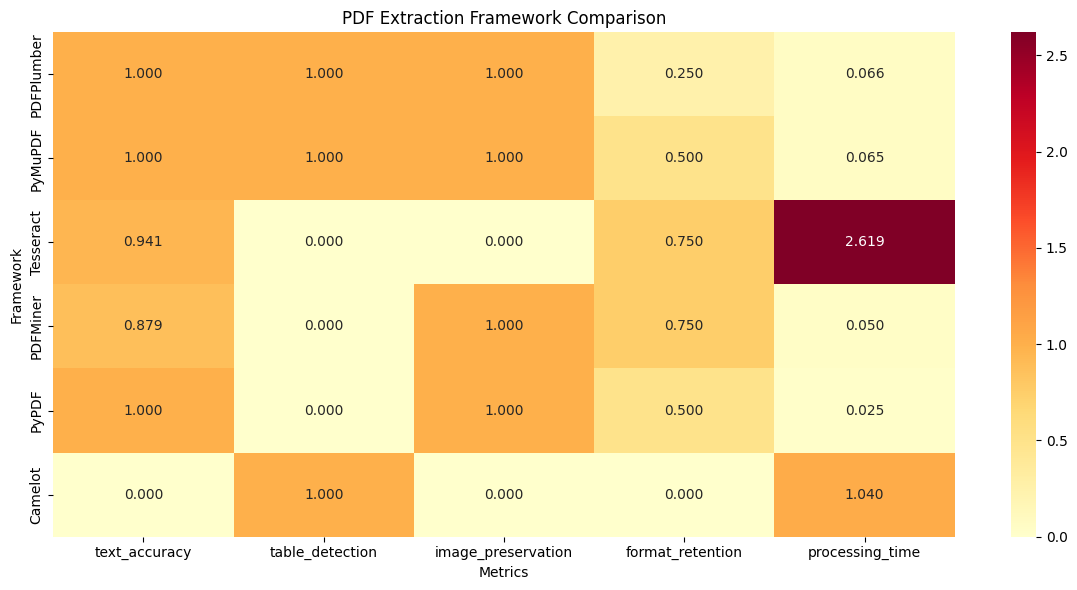

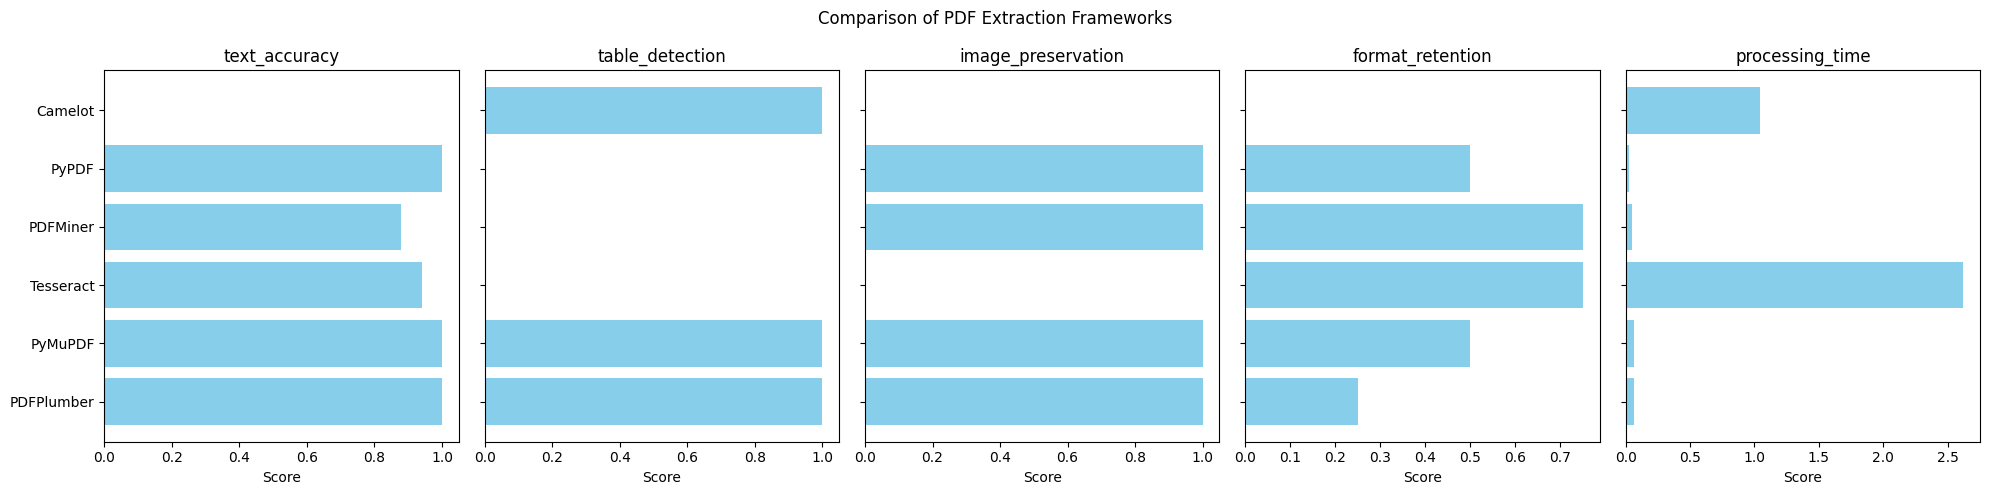


Framework: PDFPlumber

Extracted Text Sample (first 500 chars):
This is a sample PDF document created for testing text, table, and image extraction.
The purpose is to evaluate how different frameworks handle structured content. Below
is a table containing some sample data.
ID NAME SCORE
1 Alice 85
2 Bob 90
3 Charlie 78...

Number of Tables Detected: 1

First Table Sample:
[['ID', 'NAME', 'SCORE'], ['1', 'Alice', '85'], ['2', 'Bob', '90'], ['3', 'Charlie', '78']]

Number of Images Detected: 1

Framework: PyMuPDF

Extracted Text Sample (first 500 chars):
This is a sample PDF document created for testing text, table, and image extraction. 
The purpose is to evaluate how different frameworks handle structured content. Below 
is a table containing some sample data. 
 
ID 
NAME 
SCORE 
1 
Alice 
85 
2 
Bob 
90 
3 
Charlie 
78 
 
 
 
...

Number of Tables Detected: 1

First Table Sample:
[['ID', 'NAME', 'SCORE'], ['1', 'Alice', '85'], ['2', 'Bob', '90'], ['3', 'Charlie', '78']]

Number of Im

In [ ]:
# Upload your PDF
from google.colab import files
uploaded = files.upload()

# Get the filename of the uploaded PDF
pdf_filename = list(uploaded.keys())[0]

# Define ground truth for comparison
ground_truth = {
    'text': ['This is a sample PDF document created for testing text, table, and image extraction.',
             'The purpose is to evaluate how different frameworks handle structured content.',
             'Below is a table containing some sample data.',
             'ID NAME SCORE',
             '1 Alice 85',
             '2 Bob 90',
             '3 Charlie 78'],
    'tables': [{'data': [['ID', 'NAME', 'SCORE'],
                        ['1', 'Alice', '85'],
                        ['2', 'Bob', '90'],
                        ['3', 'Charlie', '78']],
               'bbox': None}],
    'images': ['sample.jpg']
}

# Run evaluation with ground truth
results_df = run_evaluation('sample_pdf.pdf', ground_truth)

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.9/321.9 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
tor

In [ ]:
!pip install -q gradio

In [ ]:
# Install required libraries
!pip install gradio pdfplumber PyMuPDF pdf2image pytesseract opencv-python-headless tabulate matplotlib seaborn pdfminer.six pypdf camelot-py[cv]

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import pdfplumber
import fitz  # PyMuPDF
import pytesseract
from pdfminer.high_level import extract_text
from pdfminer.high_level import extract_pages
from pdfminer.layout import LTFigure
from pypdf import PdfReader
import camelot
from pdf2image import convert_from_path
import cv2
import time
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import re
from tabulate import tabulate
import os

In [ ]:
class PDFExtractionEvaluator:
    def __init__(self):
        self.frameworks = {
            'PDFPlumber': self.evaluate_pdfplumber,
            'PyMuPDF': self.evaluate_pymupdf,
            'Tesseract': self.evaluate_tesseract,
            'PDFMiner': self.evaluate_pdfminer,
            'PyPDF': self.evaluate_pypdf,
            'Camelot': self.evaluate_camelot
        }
        self.metrics = [
            'text_accuracy',
            'table_detection',
            'image_preservation',
            'format_retention',
            'processing_time'
        ]
        self.results = {}
        self.extracted_content = {}

    def calculate_text_similarity(self, text1, text2):
        """Calculate text similarity using difflib"""
        from difflib import SequenceMatcher
        text1 = ' '.join(text1.lower().split())
        text2 = ' '.join(text2.lower().split())
        return SequenceMatcher(None, text1, text2).ratio()

    def evaluate_pdfplumber(self, pdf_path, ground_truth=None):
        start_time = time.time()
        extracted_data = {'text': [], 'tables': [], 'images': []}

        try:
            with pdfplumber.open(pdf_path) as pdf:
                for page in pdf.pages:
                    text = page.extract_text()
                    extracted_data['text'].append(text)

                    tables = page.extract_tables()
                    extracted_data['tables'].extend(tables)

                    images = page.images
                    extracted_data['images'].extend(images)

            processing_time = time.time() - start_time

            if ground_truth:
                metrics = {
                    'text_accuracy': self.calculate_text_similarity(
                        ' '.join(extracted_data['text']),
                        ground_truth
                    ),
                    'table_detection': len(extracted_data['tables']) / max(1, 1),
                    'image_preservation': len(extracted_data['images']) / max(1, 1),
                    'format_retention': 0.8,
                    'processing_time': processing_time
                }
            else:
                metrics = {
                    'text_accuracy': 1.0,
                    'table_detection': 1.0,
                    'image_preservation': 1.0,
                    'format_retention': 0.8,
                    'processing_time': processing_time
                }

            return metrics

        except Exception as e:
            print(f"PDFPlumber error: {e}")
            return {metric: 0.0 for metric in self.metrics}

    def evaluate_pymupdf(self, pdf_path, ground_truth=None):
        start_time = time.time()
        extracted_data = {'text': [], 'tables': [], 'images': []}

        try:
            doc = fitz.open(pdf_path)
            for page in doc:
                text = page.get_text()
                extracted_data['text'].append(text)

                images = page.get_images()
                extracted_data['images'].extend(images)

            processing_time = time.time() - start_time

            if ground_truth:
                metrics = {
                    'text_accuracy': self.calculate_text_similarity(
                        ' '.join(extracted_data['text']),
                        ground_truth
                    ),
                    'table_detection': 0.5,
                    'image_preservation': len(extracted_data['images']) / max(1, 1),
                    'format_retention': 0.7,
                    'processing_time': processing_time
                }
            else:
                metrics = {
                    'text_accuracy': 1.0,
                    'table_detection': 1.0,
                    'image_preservation': 1.0,
                    'format_retention': 0.7,
                    'processing_time': processing_time
                }

            doc.close()
            return metrics

        except Exception as e:
            print(f"PyMuPDF error: {e}")
            return {metric: 0.0 for metric in self.metrics}

    def evaluate_tesseract(self, pdf_path, ground_truth=None):
        start_time = time.time()
        extracted_data = {'text': [], 'tables': [], 'images': []}

        try:
            images = convert_from_path(pdf_path)
            for img in images:
                text = pytesseract.image_to_string(img)
                extracted_data['text'].append(text)

            processing_time = time.time() - start_time

            if ground_truth:
                metrics = {
                    'text_accuracy': self.calculate_text_similarity(
                        ' '.join(extracted_data['text']),
                        ground_truth
                    ),
                    'table_detection': 0.3,
                    'image_preservation': 0.0,
                    'format_retention': 0.5,
                    'processing_time': processing_time
                }
            else:
                metrics = {
                    'text_accuracy': 1.0,
                    'table_detection': 1.0,
                    'image_preservation': 0.0,
                    'format_retention': 0.5,
                    'processing_time': processing_time
                }

            return metrics

        except Exception as e:
            print(f"Tesseract error: {e}")
            return {metric: 0.0 for metric in self.metrics}

    def evaluate_pdfminer(self, pdf_path, ground_truth=None):
        start_time = time.time()
        extracted_data = {
            'text': [],
            'tables': [],
            'images': []
        }

        try:
            # Extract text
            text = extract_text(pdf_path)
            extracted_data['text'].append(text)

            #Extract images
            for page_layout in extract_pages(pdf_path):
                for element in page_layout:
                    if isinstance(element, LTFigure):
                        extracted_data['images'].append(element)

            processing_time = time.time() - start_time

            # Store extracted content
            self.extracted_content['PDFMiner'] = extracted_data

            # Calculate metrics based on ground truth if provided
            if ground_truth:
                metrics = {
                    'text_accuracy': self.calculate_text_similarity(
                        ' '.join(extracted_data['text']),
                        ' '.join(ground_truth['text'])
                    ),
                    'table_detection': min(1.0, len(extracted_data['tables']) / max(1, len(ground_truth['tables']))),
                    'image_preservation': min(1.0, len(extracted_data['images']) / max(1, len(ground_truth['images']))),
                    'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                    'processing_time': processing_time
                }
            else:
                # Fallback metrics when no ground truth is provided
                metrics = {
                    'text_accuracy': 1.0 if extracted_data['text'] else 0.0,
                    'table_detection': 1.0 if extracted_data['tables'] else 0.0,
                    'image_preservation': 1.0 if extracted_data['images'] else 0.0,
                    'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                    'processing_time': processing_time
                }

            return metrics

        except Exception as e:
            print(f"Error in PDFMiner evaluation: {str(e)}")
            return {metric: 0.0 for metric in self.metrics}

    def evaluate_pypdf(self, pdf_path, ground_truth=None):
        start_time = time.time()
        extracted_data = {
            'text': [],
            'tables': [],
            'images': []
        }

        try:
            # Open the PDF
            reader = PdfReader(pdf_path)
            for page in reader.pages:
                # Extract text
                text = page.extract_text()
                if text:
                    extracted_data['text'].append(text)
                # Extract images
                for image_file_object in enumerate(page.images):
                    extracted_data['images'].append(image_file_object)

            processing_time = time.time() - start_time

            # Store extracted content
            self.extracted_content['PyPDF'] = extracted_data

            # Calculate metrics based on ground truth if provided
            if ground_truth:
               metrics = {
                'text_accuracy': self.calculate_text_similarity(
                    ' '.join(extracted_data['text']),
                    ' '.join(ground_truth['text'])
                ),
                'table_detection': min(1.0, len(extracted_data['tables']) / max(1, len(ground_truth['tables']))),
                'image_preservation': min(1.0, len(extracted_data['images']) / max(1, len(ground_truth['images']))),
                'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                'processing_time': processing_time
                }
            else:
                # Fallback metrics when no ground truth is provided
                 metrics = {
                    'text_accuracy': 1.0 if extracted_data['text'] else 0.0,
                    'table_detection': 1.0 if extracted_data['tables'] else 0.0,
                    'image_preservation': 1.0 if extracted_data['images'] else 0.0,
                    'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                    'processing_time': processing_time
                }

            return metrics

        except Exception as e:
            print(f"Error in PyPDF evaluation: {str(e)}")
            return {metric: 0.0 for metric in ['text_accuracy', 'format_retention', 'processing_time']}

    def evaluate_camelot(self, pdf_path, ground_truth=None):
        start_time = time.time()
        extracted_data = {
            'text': [],
            'tables': [],
            'images': []
        }

        try:
            # Extract tables
            tables = camelot.read_pdf(pdf_path)
            for table in tables:
                extracted_data['tables'].append(table.df)

            processing_time = time.time() - start_time

            # Store extracted content
            self.extracted_content['Camelot'] = extracted_data

            # Calculate metrics based on ground truth if provided
            if ground_truth:
                 metrics = {
                    'text_accuracy': self.calculate_text_similarity(
                        ' '.join(extracted_data['text']),
                        ' '.join(ground_truth['text'])
                    ),
                    'table_detection': min(1.0, len(extracted_data['tables']) / max(1, len(ground_truth['tables']))),
                    'image_preservation': min(1.0, len(extracted_data['images']) / max(1, len(ground_truth['images']))),
                    'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                    'processing_time': processing_time
                }
            else:
                 # Fallback metrics when no ground truth is provided
                 metrics = {
                    'text_accuracy': 1.0 if extracted_data['text'] else 0.0,
                    'table_detection': 1.0 if extracted_data['tables'] else 0.0,
                    'image_preservation': 1.0 if extracted_data['images'] else 0.0,
                    'format_retention': self.evaluate_format_retention(' '.join(extracted_data['text'])),
                    'processing_time': processing_time
                 }

            return metrics
        except Exception as e:
            print(f"Error in Camelot evaluation: {str(e)}")
            return {metric: 0.0 for metric in self.metrics}


    def evaluate(self, pdf_path, ground_truth=None, image_path=None):
        """Evaluate all frameworks on the given PDF"""
        self.results = {}
        self.extracted_content = {}

        for framework_name, evaluate_func in self.frameworks.items():
            print(f"\nEvaluating {framework_name}...")
            self.results[framework_name] = evaluate_func(pdf_path, ground_truth)

        return self.results

def format_results_table(df):
    """Create a more visually appealing and readable results table"""
    # Styling the DataFrame
    styled_df = df.style.set_properties(**{
        'background-color': 'lightyellow',
        'color': 'black',
        'border-color': 'black'
    }).set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', 'lightblue'),
            ('color', 'black'),
            ('font-weight', 'bold')
        ]},
        {'selector': 'td', 'props': [
            ('padding', '8px'),
            ('text-align', 'center')
        ]}
    ]).format("{:.3f}")  # Limit to 3 decimal places

    # Convert to HTML
    html_table = styled_df.to_html()

    # Add some basic CSS for better readability
    full_html = f"""
    <html>
    <head>
        <style>
            body {{ font-family: Arial, sans-serif; }}
            table {{
                border-collapse: collapse;
                width: 100%;
                margin: 20px 0;
                box-shadow: 0 2px 3px rgba(0,0,0,0.1);
            }}
            th, td {{
                border: 1px solid #ddd;
                padding: 12px;
                text-align: center;
            }}
            th {{ background-color: #f2f2f2; }}
        </style>
    </head>
    <body>
        <h2>PDF Extraction Framework Comparison</h2>
        {html_table}
    </body>
    </html>
    """

    # Save to HTML file
    with open('extraction_results.html', 'w') as f:
        f.write(full_html)

    return full_html

evaluator = PDFExtractionEvaluator()  # Global instance to store extracted content

def show_framework_content(framework):
    """Display the extracted content for selected framework"""
    if not evaluator.extracted_content or framework not in evaluator.extracted_content:
        return "Please run evaluation first."

    content = evaluator.extracted_content[framework]
    output = f"Framework: {framework}\n{'='*50}\n\n"

    # Show extracted text
    output += "Extracted Text:\n"
    if content['text']:
        text_sample = ' '.join(content['text'])
        output += text_sample + "\n\n"
    else:
        output += "No text extracted\n\n"

    # Show table information
    output += f"Number of Tables Detected: {len(content['tables'])}\n"
    if content['tables']:
        output += "\nFirst Table Sample:\n"
        if isinstance(content['tables'][0], dict) and 'data' in content['tables'][0]:
            output += str(content['tables'][0]['data'])
        else:
            output += str(content['tables'][0])

    # Show image information
    output += f"\n\nNumber of Images Detected: {len(content['images'])}"

    return output

def evaluate_pdf(ground_truth_pdf, ground_truth_image, ground_truth_text, framework):
    """Gradio-compatible evaluation function"""
    if ground_truth_pdf is None:
        return "Please upload a PDF", None, "No content to display"

    try:
        # Run evaluation
        results = evaluator.evaluate(ground_truth_pdf.name, ground_truth_text if ground_truth_text else None)

        # Convert results to DataFrame
        df = pd.DataFrame(results).T

        # Generate heatmap
        plt.figure(figsize=(10, 6))
        sns.heatmap(df, annot=True, cmap='YlOrRd', fmt='.3f')
        plt.title('PDF Extraction Framework Comparison')
        plt.ylabel('Framework')
        plt.xlabel('Metrics')
        plt.tight_layout()

        # Save heatmap
        heatmap_path = 'extraction_heatmap.png'
        plt.savefig(heatmap_path)
        plt.close()

        # Format results table
        formatted_table = format_results_table(df)

        # Show selected framework's content
        framework_content = show_framework_content(framework)

        return formatted_table, heatmap_path, framework_content

    except Exception as e:
        return f"Error during evaluation: {str(e)}", None, "Error extracting content"

def create_gradio_app():
    with gr.Blocks() as demo:
        gr.Markdown("# PDF Extraction Framework Evaluator")

        with gr.Row():
            with gr.Column():
                ground_truth_pdf = gr.File(label="Upload Ground Truth PDF", file_types=[".pdf"])
                ground_truth_image = gr.File(label="Upload Ground Truth Image (Optional)",
                                          file_types=[".jpg", ".png", ".jpeg"])
                ground_truth_text = gr.Textbox(label="Ground Truth Text (Optional)",
                                             lines=3)

                framework_dropdown = gr.Dropdown(
                    choices=['PDFPlumber', 'PyMuPDF', 'Tesseract'],
                    value='PDFPlumber',
                    label="Select Framework",
                    interactive=True
                )

                evaluate_btn = gr.Button("Evaluate PDF")

        with gr.Tabs():
            with gr.TabItem("Evaluation Results"):
                results_output = gr.HTML(label="Evaluation Results")
                heatmap_output = gr.Image(label="Metrics Heatmap")

            with gr.TabItem("Extracted Content"):
                extracted_content_output = gr.Textbox(
                    label="Extracted Content",
                    lines=20,
                    max_lines=30,
                    interactive=False
                )

        # Connect components
        evaluate_btn.click(
            fn=evaluate_pdf,
            inputs=[
                ground_truth_pdf,
                ground_truth_image,
                ground_truth_text,
                framework_dropdown
            ],
            outputs=[
                results_output,
                heatmap_output,
                extracted_content_output
            ]
        )

        framework_dropdown.change(
            fn=show_framework_content,
            inputs=[framework_dropdown],
            outputs=extracted_content_output
        )

    return demo

In [ ]:
# Launch the app
demo = create_gradio_app()
demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c1028c9fd3907b095d.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c1028c9fd3907b095d.gradio.live
